# Intro

In [5]:
# Import required libs

import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
import warnings

from scipy.linalg import eigh
from scipy.ndimage import median_filter, uniform_filter
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from skimage.feature import local_binary_pattern
from skimage.filters import gaussian, sobel
from skimage.filters.rank import entropy
from skimage.morphology import disk

In [6]:
%pip install tabulate
%pip install torch torchvision


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: /Users/Maksym_Rybnytskyi/Library/CloudStorage/OneDrive-EPAM/Університет/Аспірантура/PhD/Repositories/xgboost-classifiers/my_env_name/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: /Users/Maksym_Rybnytskyi/Library/CloudStorage/OneDrive-EPAM/Університет/Аспірантура/PhD/Repositories/xgboost-classifiers/my_env_name/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Load data
def load_pavia_data(data_path, gt_path):
    """Завантажує дані та маску з .mat файлів."""
    data = sio.loadmat(data_path)['paviaU']
    gt = sio.loadmat(gt_path)['paviaU_gt']
    return data, gt

In [8]:
# Get RGB
def get_rgb_image(data, bands=(55, 30, 10)):
    """
    Створює RGB зображення на основі обраних каналів.
    bands: кортеж (Red, Green, Blue) індексів каналів.
    """
    # Вибираємо канали
    rgb = data[:, :, bands].astype(np.float32)
    
    # Нормалізація (Min-Max Scaling) для коректного відображення
    for i in range(3):
        min_val = rgb[:,:,i].min()
        max_val = rgb[:,:,i].max()
        if max_val - min_val > 0:
            rgb[:,:,i] = (rgb[:,:,i] - min_val) / (max_val - min_val)
            
    return rgb

In [9]:
# Visualize dataset
def visualize_pavia(data, gt, rgb_bands=(55, 30, 10)):
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # 1. Візуалізація Pseudo-RGB
    rgb_img = get_rgb_image(data, rgb_bands)
    ax[0].imshow(rgb_img)
    ax[0].set_title(f'Pseudo-RGB (Bands: {rgb_bands})')
    ax[0].axis('off')

    # 2. Оновлена палітра (ПЕРШИЙ КОЛІР — БІЛИЙ)
    class_colors = [
        '#FFFFFF', # 0: Undefined -> ТЕПЕР БІЛИЙ
        '#D8BFD8', # 1: Asphalt
        '#00FF00', # 2: Meadow
        '#00FFFF', # 3: Gravel
        '#006400', # 4: Trees
        '#FF00FF', # 5: Metal sheets
        '#FF8C00', # 6: Bare soil
        '#9400D3', # 7: Bitumen
        '#FF0000', # 8: Bricks
        '#FFFF00'  # 9: Shadows
    ]
    
    cmap = ListedColormap(class_colors)
    
    # Відображення маски
    im = ax[1].imshow(gt, cmap=cmap)
    ax[1].set_title('Ground Truth (White Background)')
    ax[1].axis('off')
    
    # 3. Легенда
    class_names = [
        'Undefined', 'Asphalt', 'Meadow', 'Gravel', 'Trees', 
        'Metal sheets', 'Bare soil', 'Bitumen', 'Bricks', 'Shadows'
    ]
    
    cb = plt.colorbar(im, ax=ax[1], ticks=range(10), fraction=0.046, pad=0.04)
    cb.ax.set_yticklabels(class_names)

    plt.tight_layout()
    plt.show()    

In [10]:
# Compare pixels power
def plot_spectral_signature(data, gt, pixel_coords):
    """
    Відображає спектральний профіль конкретного пікселя.
    pixel_coords: список кортежів (y, x)
    """
    plt.figure(figsize=(10, 5))
    for y, x in pixel_coords:
        label = f"Pixel ({y},{x}) - Class {gt[y, x]}"
        plt.plot(data[y, x, :], label=label)
    
    plt.title("Спектральні профілі пікселів")
    plt.xlabel("Номер каналу (Band)")
    plt.ylabel("Інтенсивність")
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
# Add S&P noise
def add_sp_noise_cube(cube_data, noise_ratio=0.05):
    """
    Додає імпульсний шум (Salt & Pepper) до гіперспектрального куба (всі канали).
    Симулює втрату пакетів даних або апаратні збої.
    """
    print(f"[*] Генерування шуму Salt & Pepper (Інтенсивність: {noise_ratio * 100}%)...")
    noisy_cube = np.copy(cube_data)
    
    # Визначаємо глобальні мінімум та максимум для датасету
    val_min = np.min(cube_data)
    val_max = np.max(cube_data)
    
    # Створюємо матрицю випадкових ймовірностей від 0 до 1
    random_matrix = np.random.rand(*cube_data.shape)
    
    # Pepper (Чорні пікселі) - половина від заданого шуму
    noisy_cube[random_matrix < (noise_ratio / 2.0)] = val_min
    
    # Salt (Білі пікселі) - інша половина
    noisy_cube[(random_matrix >= (noise_ratio / 2.0)) & (random_matrix < noise_ratio)] = val_max
    
    return noisy_cube

In [12]:
# Calculate MNF
def perform_mnf(cube_data, n_components=15):
    """
    Виконує перетворення MNF із регуляризацією для стійкості до імпульсного шуму.
    """
    h, w, b = cube_data.shape
    cube_2d = cube_data.reshape(h * w, b)
    
    print("[*] 1/4: Оцінка матриці коваріації шуму...")
    noise_diff = cube_data[:, :-1, :] - cube_data[:, 1:, :]
    noise_2d = noise_diff.reshape(-1, b)
    cov_noise = np.cov(noise_2d, rowvar=False)
    
    # ВИПРАВЛЕННЯ 1: Регуляризація матриці шуму (стабілізація)
    cov_noise = cov_noise + np.eye(b) * 1e-5
    
    print("[*] 2/4: Оцінка матриці коваріації даних...")
    cov_data = np.cov(cube_2d, rowvar=False)
    
    print("[*] 3/4: Розв'язання узагальненої задачі на власні значення...")
    eigenvalues, eigenvectors = eigh(cov_data, cov_noise)
    
    print(f"[*] 4/4: Сортування та проекція на {n_components} компонент...")
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    
    w_reduce = eigenvectors[:, :n_components]
    reduced_2d = np.dot(cube_2d, w_reduce)
    
    return reduced_2d.reshape(h, w, n_components)

In [13]:
def extract_teg_v_matrix(cube, gt_mask):
    """
    Екстрагує Multi-Scale TEG-V (Texture-Entropy-Gradient-Variance) ознаки.
    1. Median Preprocessing (3x3)
    2. Multi-Scale Sobel (sigma=0, 1, 3)
    3. Multi-Scale Entropy (disk 3, 5, 7)
    4. Multi-Scale LBP (radii 1, 2, 3)
    5. Multi-Scale Variance (window 5x5, 7x7)
    """
    print("[*] Початок екстракції Multi-Scale TEG-V ознак...")
    rgb = get_rgb_image(cube)
    h, w, _ = rgb.shape
    features = [rgb] # Базові RGB канали
    
    lbp_configs = [(1, 8), (2, 16), (3, 24)]
    entropy_radii = [3, 5, 7]
    sobel_sigmas = [0, 1, 3]
    variance_windows = [5, 7]

    for ch_idx in range(3):
        ch_raw = rgb[:, :, ch_idx]
        
        # 1. Median Preprocessing
        ch = median_filter(ch_raw, size=3)
        
        # 2. Multi-Scale Sobel
        for sigma in sobel_sigmas:
            ch_input = gaussian(ch, sigma=sigma) if sigma > 0 else ch
            grad = sobel(ch_input)
            features.append(grad[:, :, np.newaxis])

        # 3. Multi-Scale Entropy
        ch_8bit = (ch * 255).astype(np.uint8)
        for r in entropy_radii:
            ent = entropy(ch_8bit, disk(r))
            features.append(ent[:, :, np.newaxis])

        # 4. Multi-Scale LBP
        for r, p in lbp_configs:
            lbp_map = local_binary_pattern(ch, p, r, method='uniform')
            lbp_norm = lbp_map / (lbp_map.max() + 1e-6)
            features.append(lbp_norm[:, :, np.newaxis])

        # 5. Multi-Scale Variance (Fast implementation using uniform_filter)
        for win in variance_windows:
            mean = uniform_filter(ch, size=win)
            sq_mean = uniform_filter(ch**2, size=win)
            var = np.maximum(sq_mean - mean**2, 0) # Чисельна стабільність
            features.append(var[:, :, np.newaxis])

    teg_cube = np.concatenate(features, axis=2)
    print(f"[+] Екстракцію завершено. Кількість ознак на піксель: {teg_cube.shape[2]}")

    # Векторизація та фільтрація за маскою
    valid_mask = (gt_mask != 0)
    X_flat = teg_cube.reshape(h * w, -1)[valid_mask.flatten()]
    
    return StandardScaler().fit_transform(X_flat)

In [14]:
# Calculate learning curve
def evaluate_learning_curve(X, y, train_fractions, test_size=0.2, random_state=42):
    """
    Будує криву навчання. 
    Резервує test_size (наприклад, 20%) для чесного тестування.
    З решти (80%) формує тренувальні вибірки різного розміру відповідно до train_fractions.
    Повертає дві метрики: F1-Macro та Overall Accuracy.
    """
    # 1. Формуємо фіксовану тестову вибірку та пул для тренування
    X_train_pool, X_test, y_train_pool, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    total_samples = len(y)
    f1_scores = []
    accuracy_scores = []
    
    for frac in train_fractions:
        n_train_samples = int(total_samples * frac)
        n_train_samples = min(n_train_samples, len(y_train_pool))
        
        if n_train_samples < len(y_train_pool):
            X_train, _, y_train, _ = train_test_split(
                X_train_pool, y_train_pool, train_size=n_train_samples, 
                stratify=y_train_pool, random_state=random_state
            )
        else:
            X_train, y_train = X_train_pool, y_train_pool
            
        # Навчаємо XGBoost
        clf = xgb.XGBClassifier(
            objective='multi:softmax',
            n_estimators=200,
            max_depth=8,
            eta=0.3,
            use_label_encoder=False,
            eval_metric='mlogloss',
            tree_method='hist',
            n_jobs=-1,
            random_state=random_state
        )
        clf.fit(X_train, y_train)
        
        # Оцінюємо на фіксованій тестовій вибірці
        y_pred = clf.predict(X_test)
        
        # Рахуємо обидві метрики
        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)
        
        f1_scores.append(f1)
        accuracy_scores.append(acc)
        
    return f1_scores, accuracy_scores

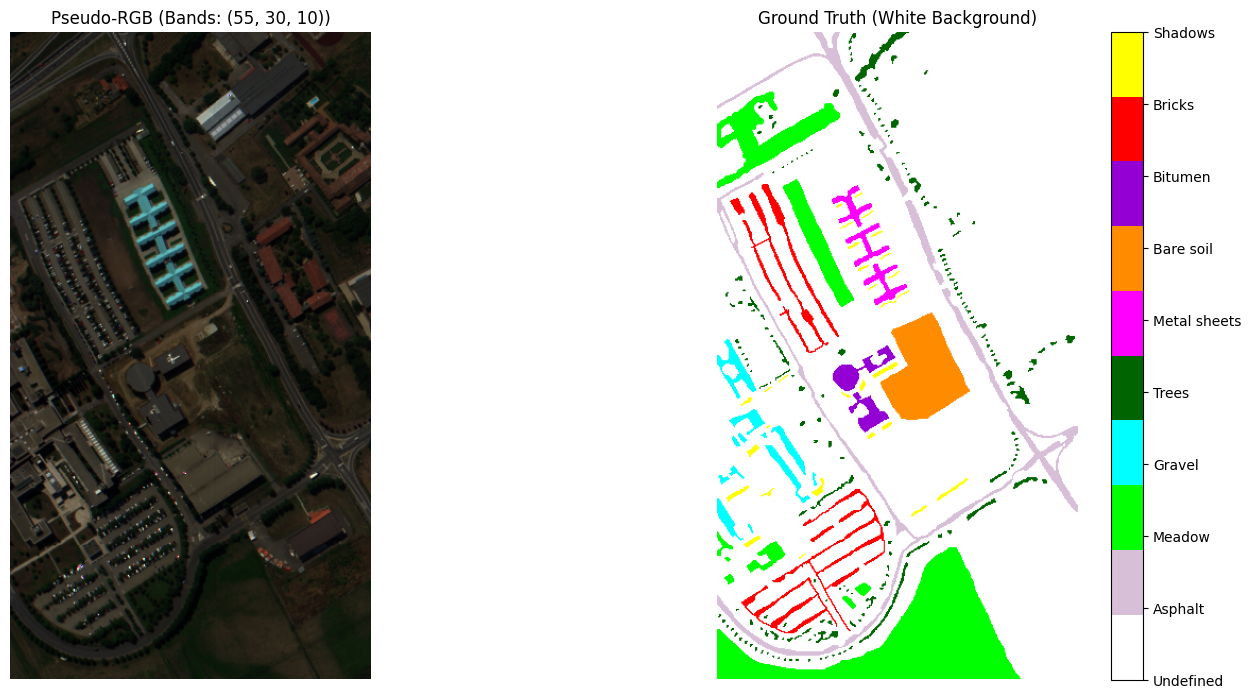

[*] Генерування шуму Salt & Pepper (Інтенсивність: 1.0%)...
[*] Генерування шуму Salt & Pepper (Інтенсивність: 5.0%)...
[*] Генерування шуму Salt & Pepper (Інтенсивність: 10.0%)...
[+] Усі зашумлені датасети успішно згенеровано!



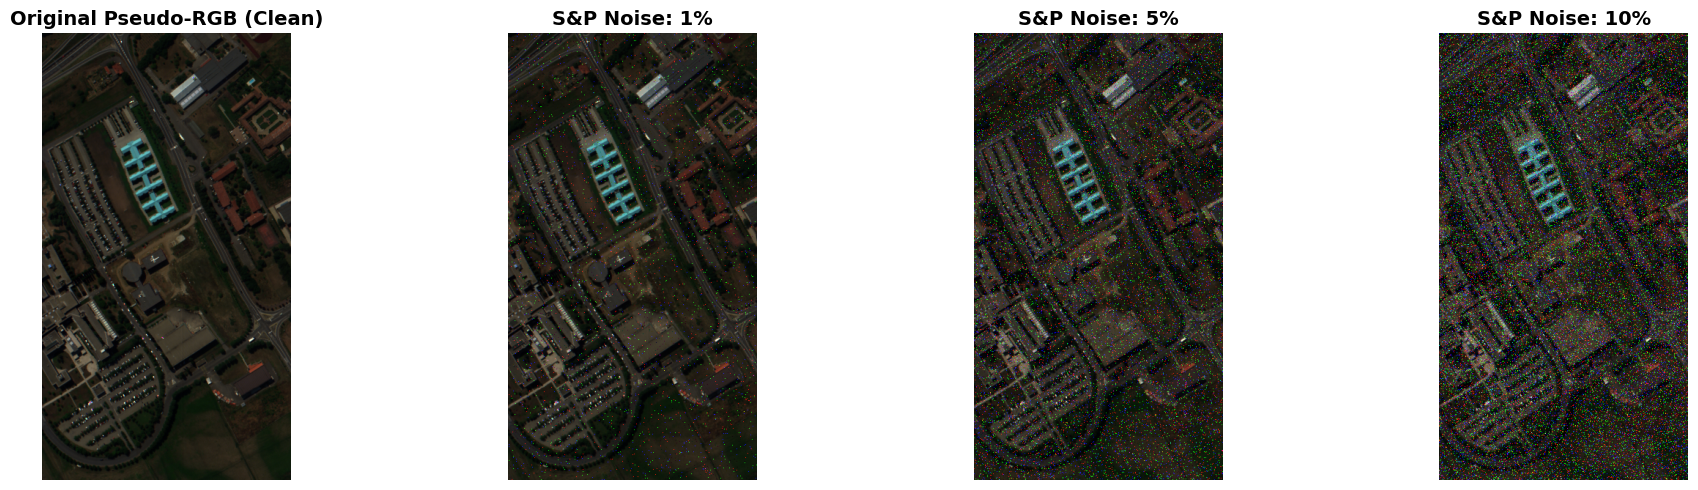


--- ЗАПУСК MNF ДЛЯ ЗАШУМЛЕНИХ ДАНИХ (103 -> 15) ---
[*] 1/4: Оцінка матриці коваріації шуму...
[*] 2/4: Оцінка матриці коваріації даних...
[*] 3/4: Розв'язання узагальненої задачі на власні значення...
[*] 4/4: Сортування та проекція на 15 компонент...

АНАЛІЗ ОБСЯГУ ДАНИХ (MNF):
Оригінальний куб:      (610, 340, 103) -> 21362200 значень
Після MNF редукції:    (610, 340, 15) -> 3111000 значень
Коефіцієнт стиснення:  Зменшено у 6.9 разів!


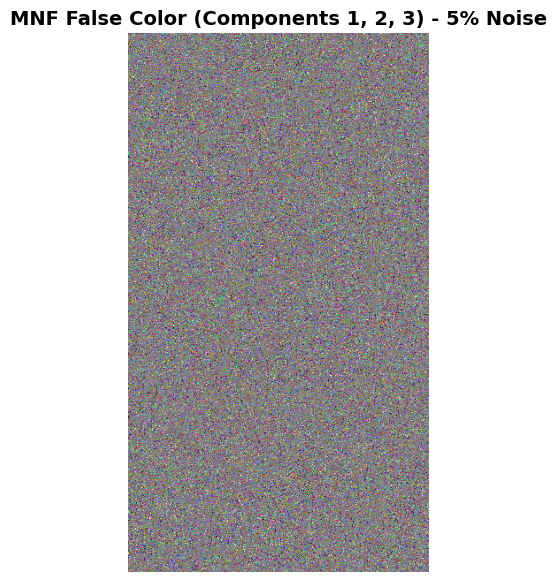


--- ЕКСТРАКЦІЯ ПРОСТОРОВИХ ОЗНАК TEG (Channel-wise) ---

АНАЛІЗ ОБСЯГУ ДАНИХ (TEG-ДЕСКРИПТОР):
Базовий RGB:           (610, 340, 3) -> 622200 значень
Загальний простір TEG: (610, 340, 18) -> 3733200 значень (18 ознак на піксель)
Економія пам'яті:      У 5.7 разів менше за оригінал (103 канали)!


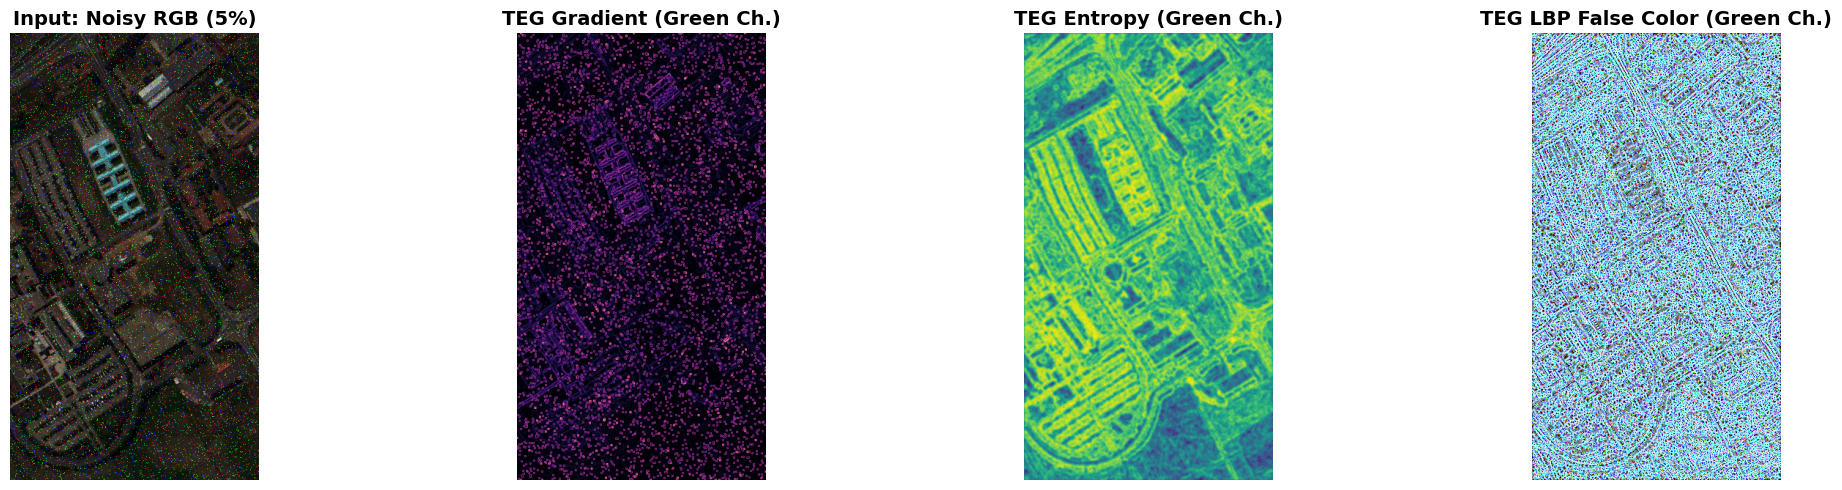


[*] Векторизація простору ознак та відкидання нерозмічених пікселів...
[*] Нормалізація ознак для XGBoost (StandardScaler)...

ФІНАЛЬНИЙ АНАЛІЗ МАТРИЦЬ ДЛЯ XGBOOST:
Кількість валідних пікселів (Y):        42776
Розмірність матриці MNF (Базлайн 2):    (42776, 15) (15 ознак)
Розмірність матриці TEG (Пропонована):  (42776, 18) (18 ознак)



In [15]:
# =============================================================================
# MAIN PIPELINE
# =============================================================================

# 1. Завантаження
data, gt = load_pavia_data('dataset/PaviaU.mat', 'dataset/PaviaU_gt.mat')

# 2. Загальна візуалізація
visualize_pavia(data, gt)

# # 3. Аналіз спектру конкретних об'єктів (наприклад, асфальт vs дерева)
# # Координати можна підібрати по картинці
# points = [(100, 100), (400, 200)] 
# plot_spectral_signature(data, gt, points)

# 4. Задаємо рівні стрес-тестування: 1% (легкий), 5% (екстремальний), 10% (критичний)
noise_levels = [0.01, 0.05, 0.10]
noisy_datasets = {}

# 5. Генеруємо зашумлені гіперспектральні куби для кожного рівня
for nl in noise_levels:
    noisy_datasets[nl] = add_sp_noise_cube(data, noise_ratio=nl)
print("[+] Усі зашумлені датасети успішно згенеровано!\n")

# 6. Комплексна візуалізація деградації (RGB композити)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Базове зображення (Original)
axes[0].imshow(get_rgb_image(data))
axes[0].set_title('Original Pseudo-RGB (Clean)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Зашумлені зображення
for i, nl in enumerate(noise_levels):
    ax = axes[i + 1]
    ax.imshow(get_rgb_image(noisy_datasets[nl]))
    ax.set_title(f'S&P Noise: {int(nl*100)}%', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# ЕКСПЕРИМЕНТАЛЬНИЙ БЛОК (Стрес-тест на 5% шумі)
# =============================================================================
noise_level_target = 0.05
cube_to_reduce = noisy_datasets[noise_level_target]

# -----------------------------------------------------------------------------
# 7. БАЗЛАЙН 2: Зниження розмірності (MNF) 
# -----------------------------------------------------------------------------
n_components = 15
print(f"\n--- ЗАПУСК MNF ДЛЯ ЗАШУМЛЕНИХ ДАНИХ (103 -> {n_components}) ---")
reduced_cube_mnf = perform_mnf(cube_to_reduce, n_components=n_components)

# ВИПРАВЛЕННЯ 2: Нормалізація з використанням процентилів (Robust Scaling)
mnf_rgb = reduced_cube_mnf[:, :, :3].copy()
for i in range(3):
    # Відкидаємо 2% екстремальних значень шуму з обох боків
    min_v = np.percentile(mnf_rgb[:,:,i], 2)
    max_v = np.percentile(mnf_rgb[:,:,i], 98)
    
    # Нормалізуємо та обрізаємо значення, щоб вони були строго в межах [0, 1]
    if max_v - min_v > 0:
        mnf_rgb[:,:,i] = np.clip((mnf_rgb[:,:,i] - min_v) / (max_v - min_v), 0, 1)

print(f"\nАНАЛІЗ ОБСЯГУ ДАНИХ (MNF):")
print(f"Оригінальний куб:      {cube_to_reduce.shape} -> {cube_to_reduce.size} значень")
print(f"Після MNF редукції:    {reduced_cube_mnf.shape} -> {reduced_cube_mnf.size} значень")
print(f"Коефіцієнт стиснення:  Зменшено у {cube_to_reduce.size / reduced_cube_mnf.size:.1f} разів!")

plt.figure(figsize=(7, 7))
plt.imshow(mnf_rgb)
plt.title(f'MNF False Color (Components 1, 2, 3) - 5% Noise', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()


# -----------------------------------------------------------------------------
# 8-9. ЗАПРОПОНОВАНА МОДЕЛЬ: Поканальна екстракція TEG-дескриптора (18 ознак)
# -----------------------------------------------------------------------------
warnings.filterwarnings('ignore')

print("\n--- ЕКСТРАКЦІЯ ПРОСТОРОВИХ ОЗНАК TEG (Channel-wise) ---")
noisy_rgb = get_rgb_image(cube_to_reduce)
lbp_configs = [(1, 8), (2, 16), (3, 24)]

# Список для зберігання всіх ознак: починаємо з 3-х базових RGB каналів
teg_features_list = [noisy_rgb]

# Змінні суто для візуалізації (збережемо карти для Зеленого каналу, індекс 1)
vis_grad, vis_ent, vis_lbp = None, None, None

for ch_idx in range(3):
    channel = noisy_rgb[:, :, ch_idx]
    
    # 1. GRADIENT (Sobel)
    grad = sobel(channel)
    teg_features_list.append(grad[:, :, np.newaxis])
    
    # 2. ENTROPY
    ch_8bit = (channel * 255).astype(np.uint8)
    ent = entropy(ch_8bit, disk(3))
    teg_features_list.append(ent[:, :, np.newaxis])
    
    # 3. TEXTURE (LBP - 3 масштаби)
    lbp_channels = []
    for r, p in lbp_configs:
        lbp_map = local_binary_pattern(channel, p, r, method='uniform')
        lbp_norm = lbp_map / lbp_map.max()
        lbp_channels.append(lbp_norm[:, :, np.newaxis])
        teg_features_list.append(lbp_norm[:, :, np.newaxis])
    
    # Зберігаємо карти зеленого каналу для малювання графіків
    if ch_idx == 1: 
        vis_grad = grad
        vis_ent = ent
        vis_lbp = np.concatenate(lbp_channels, axis=2)

# Об'єднуємо всі 18 ознак в один куб (H, W, 18)
teg_cube = np.concatenate(teg_features_list, axis=2)

print(f"\nАНАЛІЗ ОБСЯГУ ДАНИХ (TEG-ДЕСКРИПТОР):")
print(f"Базовий RGB:           {noisy_rgb.shape} -> {noisy_rgb.size} значень")
print(f"Загальний простір TEG: {teg_cube.shape} -> {teg_cube.size} значень (18 ознак на піксель)")
print(f"Економія пам'яті:      У {cube_to_reduce.size / teg_cube.size:.1f} разів менше за оригінал (103 канали)!")

# --- ВІЗУАЛІЗАЦІЯ (Лише для Зеленого каналу) ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(noisy_rgb)
axes[0].set_title('Input: Noisy RGB (5%)', fontsize=14, fontweight='bold')
axes[0].axis('off')

im1 = axes[1].imshow(vis_grad, cmap='magma')
axes[1].set_title('TEG Gradient (Green Ch.)', fontsize=14, fontweight='bold')
axes[1].axis('off')

im2 = axes[2].imshow(vis_ent, cmap='viridis')
axes[2].set_title('TEG Entropy (Green Ch.)', fontsize=14, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(vis_lbp[:, :, :3])
axes[3].set_title('TEG LBP False Color (Green Ch.)', fontsize=14, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# --- ВЕКТОРИЗАЦІЯ ТА НОРМАЛІЗАЦІЯ ---
print("\n[*] Векторизація простору ознак та відкидання нерозмічених пікселів...")
valid_mask = (gt != 0)
h, w = gt.shape

# Базлайн 2 (MNF - 15 компонент)
reduced_cube_mnf_2d = reduced_cube_mnf.reshape(h * w, -1)

# Запропонована модель (TEG - 18 компонент)
teg_cube_2d = teg_cube.reshape(h * w, -1)

# Мітки класів
gt_flat = gt.flatten()
y = gt_flat[valid_mask.flatten()] - 1

print("[*] Нормалізація ознак для XGBoost (StandardScaler)...")
scaler = StandardScaler()
x_mnf = scaler.fit_transform(reduced_cube_mnf_2d[valid_mask.flatten()])
x_teg = scaler.fit_transform(teg_cube_2d[valid_mask.flatten()])

print("\n" + "=" * 50)
print("ФІНАЛЬНИЙ АНАЛІЗ МАТРИЦЬ ДЛЯ XGBOOST:")
print(f"Кількість валідних пікселів (Y):        {y.shape[0]}")
print(f"Розмірність матриці MNF (Базлайн 2):    {x_mnf.shape} (15 ознак)")
print(f"Розмірність матриці TEG (Пропонована):  {x_teg.shape} (18 ознак)")
print("=" * 50 + "\n")

[*] 1. Підготовка чистих даних (Оригінальні 103 канали)...
[*] 2. Виконання PCA (103 -> 15) на чистих даних...
[*] 3. Виконання MNF (103 -> 15) на чистих даних...
[*] 1/4: Оцінка матриці коваріації шуму...
[*] 2/4: Оцінка матриці коваріації даних...
[*] 3/4: Розв'язання узагальненої задачі на власні значення...
[*] 4/4: Сортування та проекція на 15 компонент...

[*] Запуск навчання XGBoost на чистих даних (це займе трохи більше часу)...
    Тренування: Clean: All 103 Channels...
    Тренування: Clean: PCA (15 comp)...
    Тренування: Clean: MNF (15 comp)...
[+] Навчання завершено!


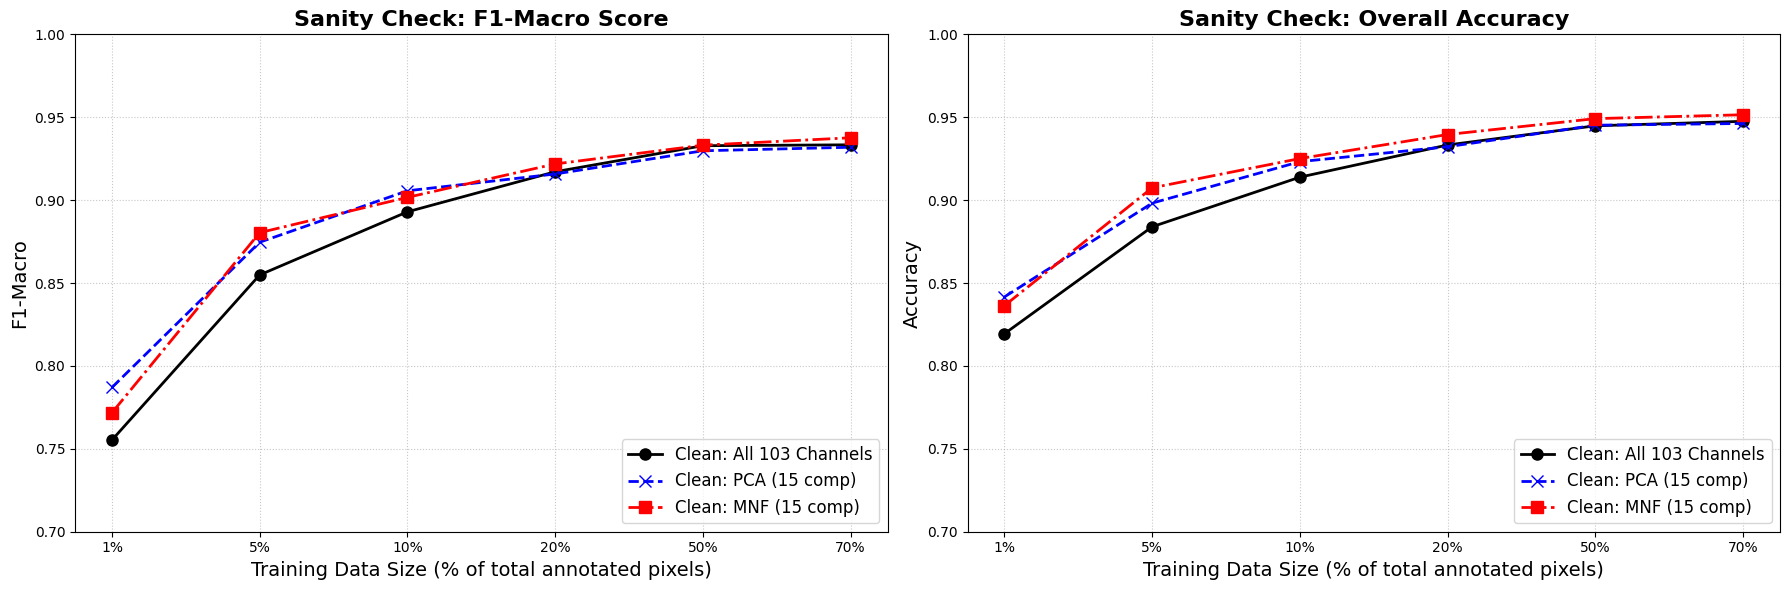


=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: F1-MACRO ===
Train Size                   1%      5%     10%     20%     50%     70%
Clean: All 103 Channels  0.7553  0.8549  0.8929  0.9171  0.9328  0.9334
Clean: PCA (15 comp)     0.7870  0.8746  0.9056  0.9158  0.9298  0.9319
Clean: MNF (15 comp)     0.7718  0.8804  0.9017  0.9218  0.9331  0.9376

=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: OVERALL ACCURACY ===
Train Size                   1%      5%     10%     20%     50%     70%
Clean: All 103 Channels  0.8194  0.8839  0.9139  0.9333  0.9448  0.9475
Clean: PCA (15 comp)     0.8416  0.8982  0.9232  0.9322  0.9452  0.9462
Clean: MNF (15 comp)     0.8364  0.9074  0.9251  0.9396  0.9492  0.9515


In [48]:
# =============================================================================
# MAIN 2: SANITY CHECK - Навчання на ЧИСТИХ даних (Без шуму)
# =============================================================================
print("[*] 1. Підготовка чистих даних (Оригінальні 103 канали)...")
valid_mask = (gt != 0)
h, w = gt.shape
gt_flat = gt.flatten()
y = gt_flat[valid_mask.flatten()] - 1 

scaler = StandardScaler()

cube_clean_2d = data.reshape(h * w, -1)
X_clean_103 = scaler.fit_transform(cube_clean_2d[valid_mask.flatten()])

print("[*] 2. Виконання PCA (103 -> 15) на чистих даних...")
pca = PCA(n_components=15)
reduced_pca_2d = pca.fit_transform(cube_clean_2d)
X_clean_pca = scaler.fit_transform(reduced_pca_2d[valid_mask.flatten()])

print("[*] 3. Виконання MNF (103 -> 15) на чистих даних...")
reduced_mnf_cube = perform_mnf(data, n_components=15)
reduced_mnf_2d = reduced_mnf_cube.reshape(h * w, -1)
X_clean_mnf = scaler.fit_transform(reduced_mnf_2d[valid_mask.flatten()])

# =============================================================================
# НАВЧАННЯ (ЧИСТІ ДАНІ)
# =============================================================================
train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]

models_to_test_clean = {
    "Clean: All 103 Channels": X_clean_103,
    "Clean: PCA (15 comp)": X_clean_pca,
    "Clean: MNF (15 comp)": X_clean_mnf
}

# Зберігаємо результати окремо
results_f1 = {}
results_acc = {}

print("\n[*] Запуск навчання XGBoost на чистих даних (це займе трохи більше часу)...")
for model_name, X_data in models_to_test_clean.items():
    print(f"    Тренування: {model_name}...")
    # Розпаковуємо обидва значення
    f1_list, acc_list = evaluate_learning_curve(X_data, y, train_fractions, test_size=0.2)
    results_f1[model_name] = f1_list
    results_acc[model_name] = acc_list

print("[+] Навчання завершено!")

# =============================================================================
# ВІЗУАЛІЗАЦІЯ (ДВА ГРАФІКИ) ТА ТАБЛИЦІ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

styles_clean = {
    "Clean: All 103 Channels": {"color": "black", "linestyle": "-", "marker": "o"},
    "Clean: PCA (15 comp)": {"color": "blue", "linestyle": "--", "marker": "x"},
    "Clean: MNF (15 comp)": {"color": "red", "linestyle": "-.", "marker": "s"}
}

# Графік 1: F1-Macro
for model_name, scores in results_f1.items():
    s = styles_clean[model_name]
    axes[0].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[0].set_title("Sanity Check: F1-Macro Score", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[0].set_ylabel("F1-Macro", fontsize=14)
axes[0].set_ylim(0.7, 1.0) 
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower right', fontsize=12)

# Графік 2: Overall Accuracy
for model_name, scores in results_acc.items():
    s = styles_clean[model_name]
    axes[1].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[1].set_title("Sanity Check: Overall Accuracy", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[1].set_ylabel("Accuracy", fontsize=14)
axes[1].set_ylim(0.7, 1.0) 
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

df_f1 = pd.DataFrame(results_f1, index=fraction_labels).T
df_f1.columns.name = "Train Size"

df_acc = pd.DataFrame(results_acc, index=fraction_labels).T
df_acc.columns.name = "Train Size"

print("\n=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: F1-MACRO ===")
print(df_f1.round(4))

print("\n=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: OVERALL ACCURACY ===")
print(df_acc.round(4))

[*] 1. Формування ізольованих просторів ознак для Ablation Study...
[-] Розмірності підготовлених даних:
    1. MNF (Upper Bound):   (42776, 15)
    2. RGB (Ablation 1):    (42776, 3)
    3. RGB+LBP (Ablation 2):(42776, 12)
    4. RGB+TEG (Proposed):  (42776, 18)

[*] 2. Запуск навчання XGBoost (це займе близько 2-3 хвилин)...
    Тренування: Baseline 2: MNF (103 channels -> 15)...
    Тренування: Ablation 1: Noisy RGB (3 features)...
    Тренування: Ablation 2: RGB + LBP (12 features)...
    Тренування: Proposed: RGB + TEG (18 features)...
[+] Навчання завершено!


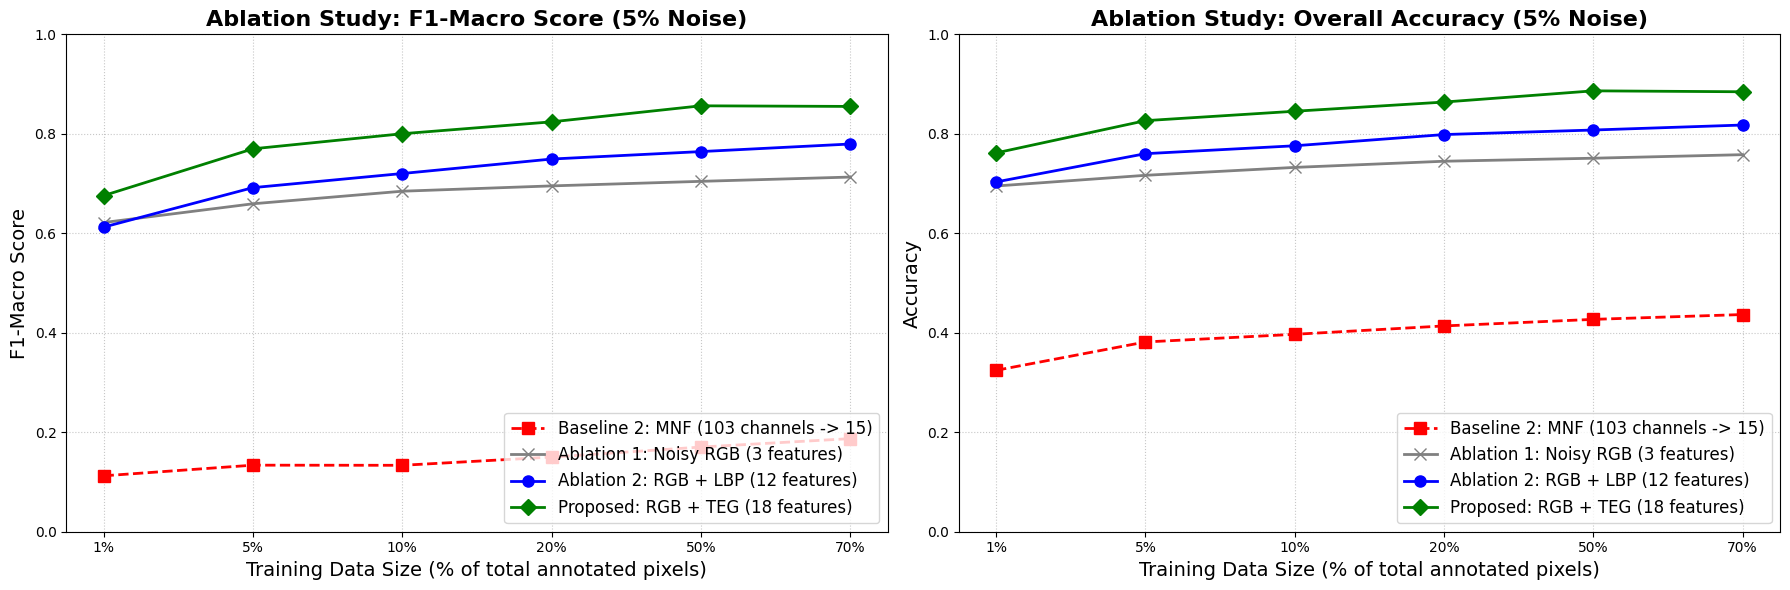


=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: F1-MACRO (5% NOISE) ===
Train Size                                1%      5%     10%     20%     50%  \
Baseline 2: MNF (103 channels -> 15)  0.1124  0.1338  0.1335  0.1501  0.1702   
Ablation 1: Noisy RGB (3 features)    0.6216  0.6593  0.6846  0.6953  0.7044   
Ablation 2: RGB + LBP (12 features)   0.6124  0.6918  0.7202  0.7493  0.7643   
Proposed: RGB + TEG (18 features)     0.6758  0.7698  0.8002  0.8240  0.8563   

Train Size                               70%  
Baseline 2: MNF (103 channels -> 15)  0.1872  
Ablation 1: Noisy RGB (3 features)    0.7130  
Ablation 2: RGB + LBP (12 features)   0.7795  
Proposed: RGB + TEG (18 features)     0.8551  

=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: OVERALL ACCURACY (5% NOISE) ===
Train Size                                1%      5%     10%     20%     50%  \
Baseline 2: MNF (103 channels -> 15)  0.3245  0.3815  0.3969  0.4137  0.4270   
Ablation 1: Noisy RGB (3 features)    0.6951  0.7166  0.7325  0.7449  0.7509   
Ablation 2: RGB 

In [35]:
# =============================================================================
# MAIN 3: ABLATION STUDY & LEARNING CURVES (XGBoost на зашумлених даних 5%)
# =============================================================================
print("[*] 1. Формування ізольованих просторів ознак для Ablation Study...")

# Отримуємо базові змінні з пам'яті (згенеровані в Main 1)
h, w = gt.shape
gt_flat = gt.flatten()
y = gt_flat[valid_mask.flatten()] - 1 # Вектор класів

scaler = StandardScaler()

# --- Набір 1: Базлайн (MNF - 15 ознак) ---
X_mnf = scaler.fit_transform(reduced_cube_mnf.reshape(h * w, -1)[valid_mask.flatten()])

# Відновлюємо списки ознак для наших моделей з teg_features_list 
rgb_features = []
rgb_lbp_features = []
rgb_teg_features = []

# noisy_rgb лежить першим у teg_features_list (індекс 0)
rgb_features.append(teg_features_list[0])
rgb_lbp_features.append(teg_features_list[0])
rgb_teg_features.append(teg_features_list[0])

# Проходимося по додаткових ознаках (з індексу 1 і далі)
idx = 1
for ch in range(3):
    grad_feat = teg_features_list[idx]
    ent_feat = teg_features_list[idx+1]
    lbp_feat_1 = teg_features_list[idx+2]
    lbp_feat_2 = teg_features_list[idx+3]
    lbp_feat_3 = teg_features_list[idx+4]
    
    rgb_lbp_features.extend([lbp_feat_1, lbp_feat_2, lbp_feat_3])
    rgb_teg_features.extend([grad_feat, ent_feat, lbp_feat_1, lbp_feat_2, lbp_feat_3])
    idx += 5

# Згортаємо у фінальні матриці та нормалізуємо
X_rgb = scaler.fit_transform(np.concatenate(rgb_features, axis=2).reshape(h * w, -1)[valid_mask.flatten()])
X_rgb_lbp = scaler.fit_transform(np.concatenate(rgb_lbp_features, axis=2).reshape(h * w, -1)[valid_mask.flatten()])
X_teg = scaler.fit_transform(np.concatenate(rgb_teg_features, axis=2).reshape(h * w, -1)[valid_mask.flatten()])

print(f"[-] Розмірності підготовлених даних:")
print(f"    1. MNF (Upper Bound):   {X_mnf.shape}")
print(f"    2. RGB (Ablation 1):    {X_rgb.shape}")
print(f"    3. RGB+LBP (Ablation 2):{X_rgb_lbp.shape}")
print(f"    4. RGB+TEG (Proposed):  {X_teg.shape}")

# =============================================================================
# 2. РОЗРАХУНОК КРИВИХ НАВЧАННЯ (LEARNING CURVES)
# =============================================================================
train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]

models_to_test = {
    "Baseline 2: MNF (103 channels -> 15)": X_mnf,
    "Ablation 1: Noisy RGB (3 features)": X_rgb,
    "Ablation 2: RGB + LBP (12 features)": X_rgb_lbp,
    "Proposed: RGB + TEG (18 features)": X_teg
}

results_f1 = {}
results_acc = {}

print("\n[*] 2. Запуск навчання XGBoost (це займе близько 2-3 хвилин)...")
for model_name, X_data in models_to_test.items():
    print(f"    Тренування: {model_name}...")
    # ВИПРАВЛЕННЯ: Тепер коректно розпаковуємо обидві метрики
    f1_list, acc_list = evaluate_learning_curve(X_data, y, train_fractions, test_size=0.2)
    results_f1[model_name] = f1_list
    results_acc[model_name] = acc_list

print("[+] Навчання завершено!")

# =============================================================================
# 3. ВІЗУАЛІЗАЦІЯ (ДВА ГРАФІКИ) ТА ГЕНЕРАЦІЯ ТАБЛИЦЬ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

styles = {
    "Baseline 2: MNF (103 channels -> 15)": {"color": "red", "linestyle": "--", "marker": "s"},
    "Ablation 1: Noisy RGB (3 features)": {"color": "gray", "linestyle": "-", "marker": "x"},
    "Ablation 2: RGB + LBP (12 features)": {"color": "blue", "linestyle": "-", "marker": "o"},
    "Proposed: RGB + TEG (18 features)": {"color": "green", "linestyle": "-", "marker": "D"}
}

# Графік 1: F1-Macro
for model_name, scores in results_f1.items():
    s = styles[model_name]
    axes[0].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[0].set_title("Ablation Study: F1-Macro Score (5% Noise)", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[0].set_ylabel("F1-Macro Score", fontsize=14)
axes[0].set_ylim(0.0, 1.0) # Залишаємо від 0, щоб побачити падіння MNF
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower right', fontsize=12)

# Графік 2: Overall Accuracy
for model_name, scores in results_acc.items():
    s = styles[model_name]
    axes[1].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[1].set_title("Ablation Study: Overall Accuracy (5% Noise)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[1].set_ylabel("Accuracy", fontsize=14)
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

# Вивід таблиць
df_f1 = pd.DataFrame(results_f1, index=fraction_labels).T
df_f1.columns.name = "Train Size"

df_acc = pd.DataFrame(results_acc, index=fraction_labels).T
df_acc.columns.name = "Train Size"

print("\n=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: F1-MACRO (5% NOISE) ===")
print(df_f1.round(4))

print("\n=== ТАБЛИЦЯ РЕЗУЛЬТАТІВ: OVERALL ACCURACY (5% NOISE) ===")
print(df_acc.round(4))

[*] 1. Ініціалізація глобального GridSearch для моделі RGB + TEG...
[*] 2. Запуск навчання (80 моделей XGBoost). Це займе час...

=== Обробка датасету: Clean Data (0% Noise) ===
    [D:8, N:200] -> F1: 0.9001
    [D:8, N:400] -> F1: 0.9013
    [D:8, N:600] -> F1: 0.9021
    [D:8, N:1000] -> F1: 0.9021
    [D:12, N:200] -> F1: 0.8961
    [D:12, N:400] -> F1: 0.8992
    [D:12, N:600] -> F1: 0.9006
    [D:12, N:1000] -> F1: 0.9018
    [D:16, N:200] -> F1: 0.8963
    [D:16, N:400] -> F1: 0.8987
    [D:16, N:600] -> F1: 0.8996
    [D:16, N:1000] -> F1: 0.9007
    [D:20, N:200] -> F1: 0.8948
    [D:20, N:400] -> F1: 0.8957
    [D:20, N:600] -> F1: 0.8955
    [D:20, N:1000] -> F1: 0.8969
    [D:30, N:200] -> F1: 0.8951
    [D:30, N:400] -> F1: 0.8970
    [D:30, N:600] -> F1: 0.8985
    [D:30, N:1000] -> F1: 0.8987
----------------------------------------
=== Обробка датасету: Light Degradation (1% Noise) ===
    [D:8, N:200] -> F1: 0.8869
    [D:8, N:400] -> F1: 0.8895
    [D:8, N:600] -> F1:

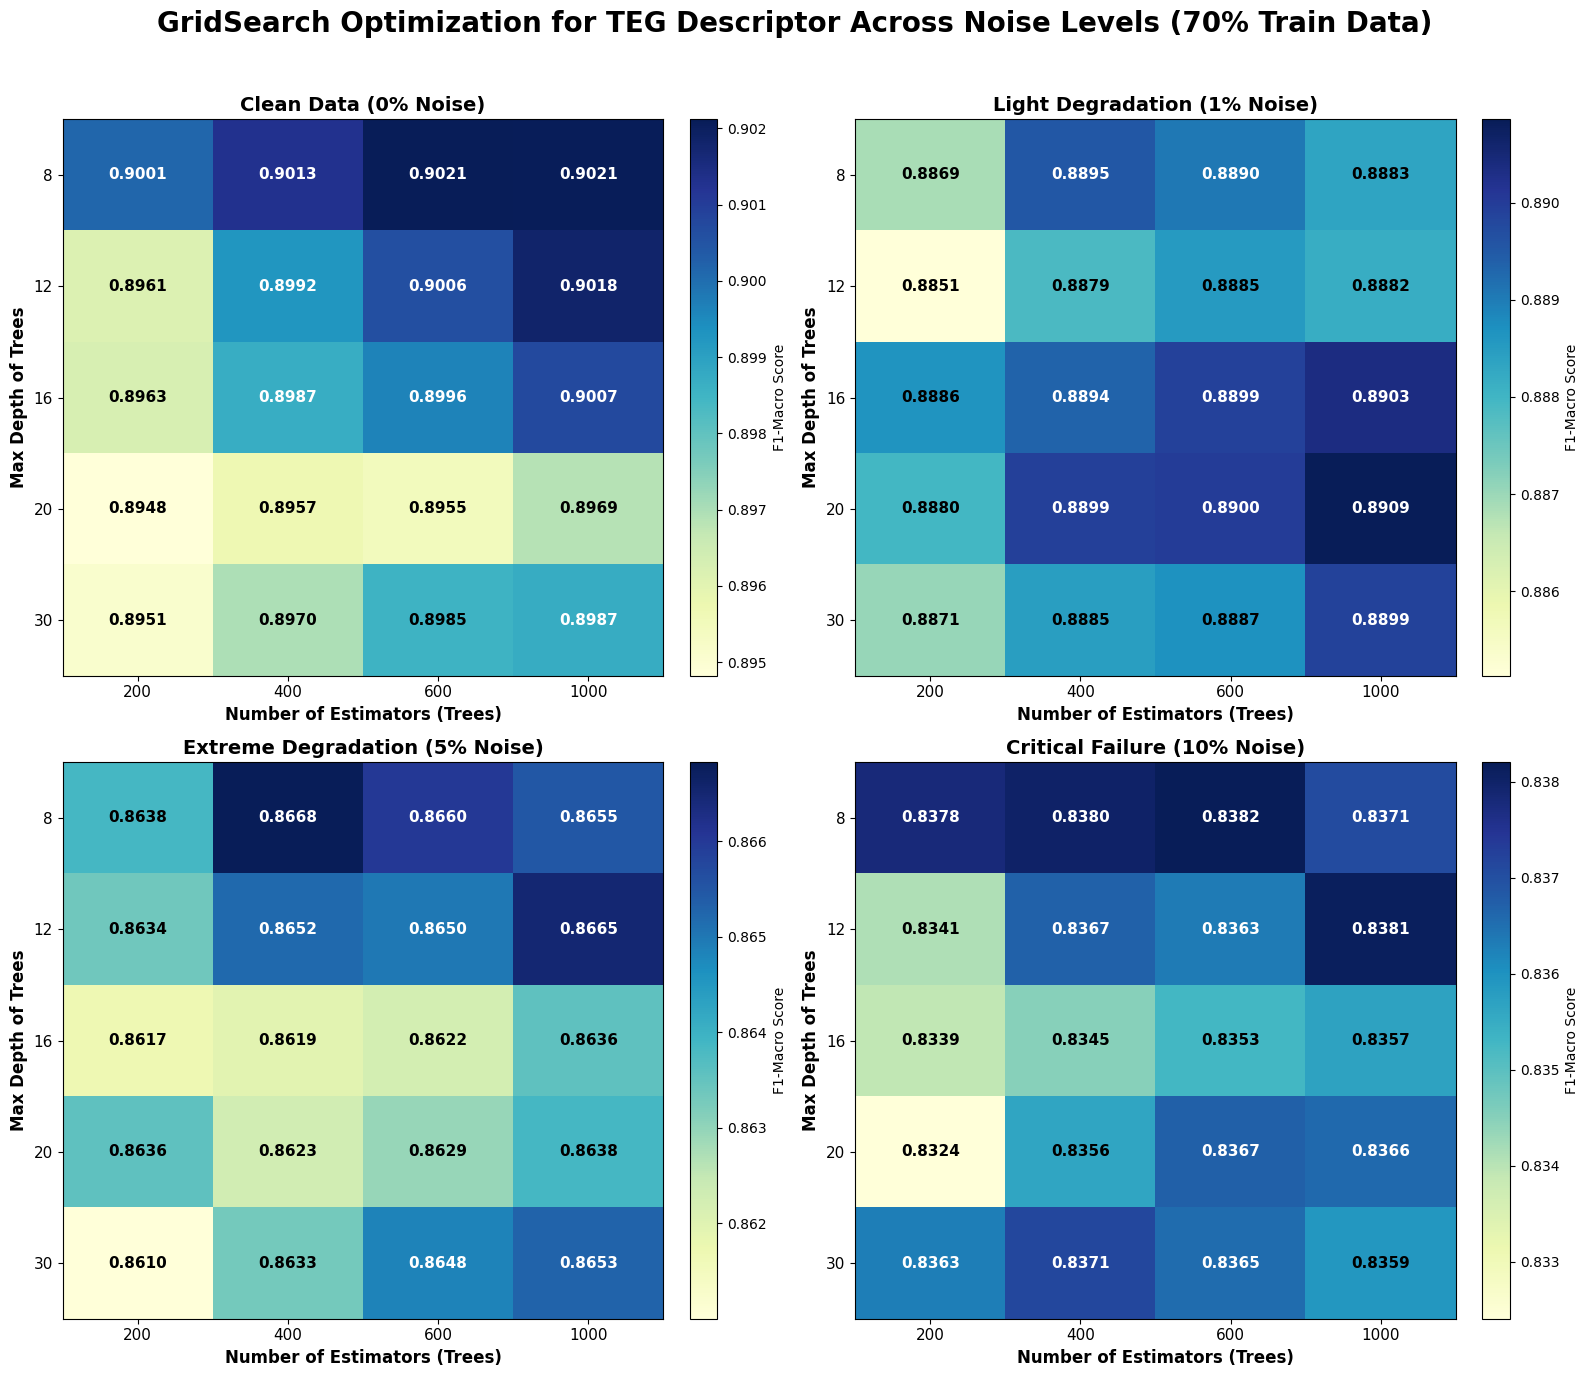


АБСОЛЮТНІ МАКСИМУМИ ДЛЯ КОЖНОГО РІВНЯ ШУМУ:
 - Clean Data (0% Noise): F1 = 0.9021 (Depth: 8, Trees: 600)
 - Light Degradation (1% Noise): F1 = 0.8909 (Depth: 20, Trees: 1000)
 - Extreme Degradation (5% Noise): F1 = 0.8668 (Depth: 8, Trees: 400)
 - Critical Failure (10% Noise): F1 = 0.8382 (Depth: 8, Trees: 600)



In [49]:
# =============================================================================
# MAIN 4: COMPREHENSIVE HYPERPARAMETER TUNING (GridSearch across Noise Levels)
# =============================================================================
warnings.filterwarnings('ignore')

# 1. Допоміжна функція для швидкої екстракції TEG (18 ознак) для будь-якого куба
def extract_teg_matrix(cube, gt_mask):
    """Екстрагує 18 ознак TEG з куба та повертає нормалізовану матрицю."""
    rgb = get_rgb_image(cube)
    features = [rgb]
    lbp_configs = [(1, 8), (2, 16), (3, 24)]
    
    for ch_idx in range(3):
        ch = rgb[:, :, ch_idx]
        features.append(sobel(ch)[:, :, np.newaxis])
        ch_8bit = (ch * 255).astype(np.uint8)
        features.append(entropy(ch_8bit, disk(3))[:, :, np.newaxis])
        for r, p in lbp_configs:
            lbp_map = local_binary_pattern(ch, p, r, method='uniform')
            features.append((lbp_map / lbp_map.max())[:, :, np.newaxis])
            
    teg_cube = np.concatenate(features, axis=2)
    h, w = gt_mask.shape
    X_flat = teg_cube.reshape(h * w, -1)[gt_mask.flatten()]
    return StandardScaler().fit_transform(X_flat)

print("[*] 1. Ініціалізація глобального GridSearch для моделі RGB + TEG...")

# Параметри експерименту
#depths = [8, 12, 16, 20, 30]
#estimators = [200, 400, 600, 1000]
depths = [8]
estimators = [10]

# Формуємо список датасетів для тестування
# Використовуємо змінні data (чиста) та noisy_datasets (з Main 1)
datasets_to_test = {
    "Clean Data (0% Noise)": data,
    "Light Degradation (1% Noise)": noisy_datasets[0.01],
    "Extreme Degradation (5% Noise)": noisy_datasets[0.05],
    "Critical Failure (10% Noise)": noisy_datasets[0.10]
}

valid_mask = (gt != 0)
y = gt.flatten()[valid_mask.flatten()] - 1

# Словник для збереження матриць результатів
all_f1_matrices = {}

print(f"[*] 2. Запуск навчання (80 моделей XGBoost). Це займе час...\n")

for name, cube in datasets_to_test.items():
    print(f"=== Обробка датасету: {name} ===")
    
    # Витягуємо ознаки TEG "на льоту"
    X_teg_current = extract_teg_matrix(cube, valid_mask)
    
    # Спліт: 70% на тренування, 30% на чесний тест (test_size=0.3)
    X_train, X_test, y_train, y_test = train_test_split(
        X_teg_current, y, test_size=0.3, stratify=y, random_state=42
    )
    
    matrix = np.zeros((len(depths), len(estimators)))
    
    for i, d in enumerate(depths):
        for j, n in enumerate(estimators):
            clf = xgb.XGBClassifier(
                objective='multi:softmax',
                n_estimators=n,
                max_depth=d,
                eta=0.3,
                use_label_encoder=False,
                eval_metric='mlogloss',
                tree_method='hist', # Критично для 1000 дерев!
                n_jobs=-1,
                random_state=42
            )
            clf.fit(X_train, y_train)
            preds = clf.predict(X_test)
            f1 = f1_score(y_test, preds, average='macro')
            matrix[i, j] = f1
            
            print(f"    [D:{d}, N:{n}] -> F1: {f1:.4f}")
            
    all_f1_matrices[name] = matrix
    print("-" * 40)

print("\n[+] Весь глобальний GridSearch успішно завершено!")

# =============================================================================
# 3. ВІЗУАЛІЗАЦІЯ: МУЛЬТИ-ТЕПЛОВА КАРТА (2x2 Grid)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, matrix) in enumerate(all_f1_matrices.items()):
    ax = axes[idx]
    
    # Малюємо теплову карту
    cax = ax.imshow(matrix, cmap='YlGnBu', aspect='auto', vmin=np.min(matrix), vmax=np.max(matrix))
    
    # Осі та підписи
    ax.set_xticks(np.arange(len(estimators)))
    ax.set_xticklabels(estimators, fontsize=11)
    ax.set_yticks(np.arange(len(depths)))
    ax.set_yticklabels(depths, fontsize=11)
    
    ax.set_xlabel('Number of Estimators (Trees)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Depth of Trees', fontsize=12, fontweight='bold')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    
    # Додаємо кольорову шкалу до кожного графіка
    cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('F1-Macro Score', fontsize=10)
    
    # Додаємо цифри в клітинки
    for i in range(len(depths)):
        for j in range(len(estimators)):
            val = matrix[i, j]
            text_color = "white" if val > np.mean(matrix) else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center", color=text_color, fontsize=11, fontweight='bold')

plt.suptitle('GridSearch Optimization for TEG Descriptor Across Noise Levels (70% Train Data)', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Вивід підсумкової аналітики
print("\n" + "=" * 60)
print("АБСОЛЮТНІ МАКСИМУМИ ДЛЯ КОЖНОГО РІВНЯ ШУМУ:")
for name, matrix in all_f1_matrices.items():
    max_idx = np.unravel_index(np.argmax(matrix), matrix.shape)
    print(f" - {name}: F1 = {matrix[max_idx]:.4f} (Depth: {depths[max_idx[0]]}, Trees: {estimators[max_idx[1]]})")
print("=" * 60 + "\n")

[*] 1. Генерація даних (Рівень шуму: 1%, Тренування: 100%)...
[*] Генерування шуму Salt & Pepper (Інтенсивність: 1.0%)...
[*] 2. Екстракція TEG ознак для ВСІЄЇ сцени (610x340)...
[*] 3. Формування тренувальної вибірки (100% від розмічених даних)...
[*] 4. Нормалізація та навчання XGBoost...
[*] 5. Прогнозування класів для всього університету...
[+] Готово! Будуємо карти...


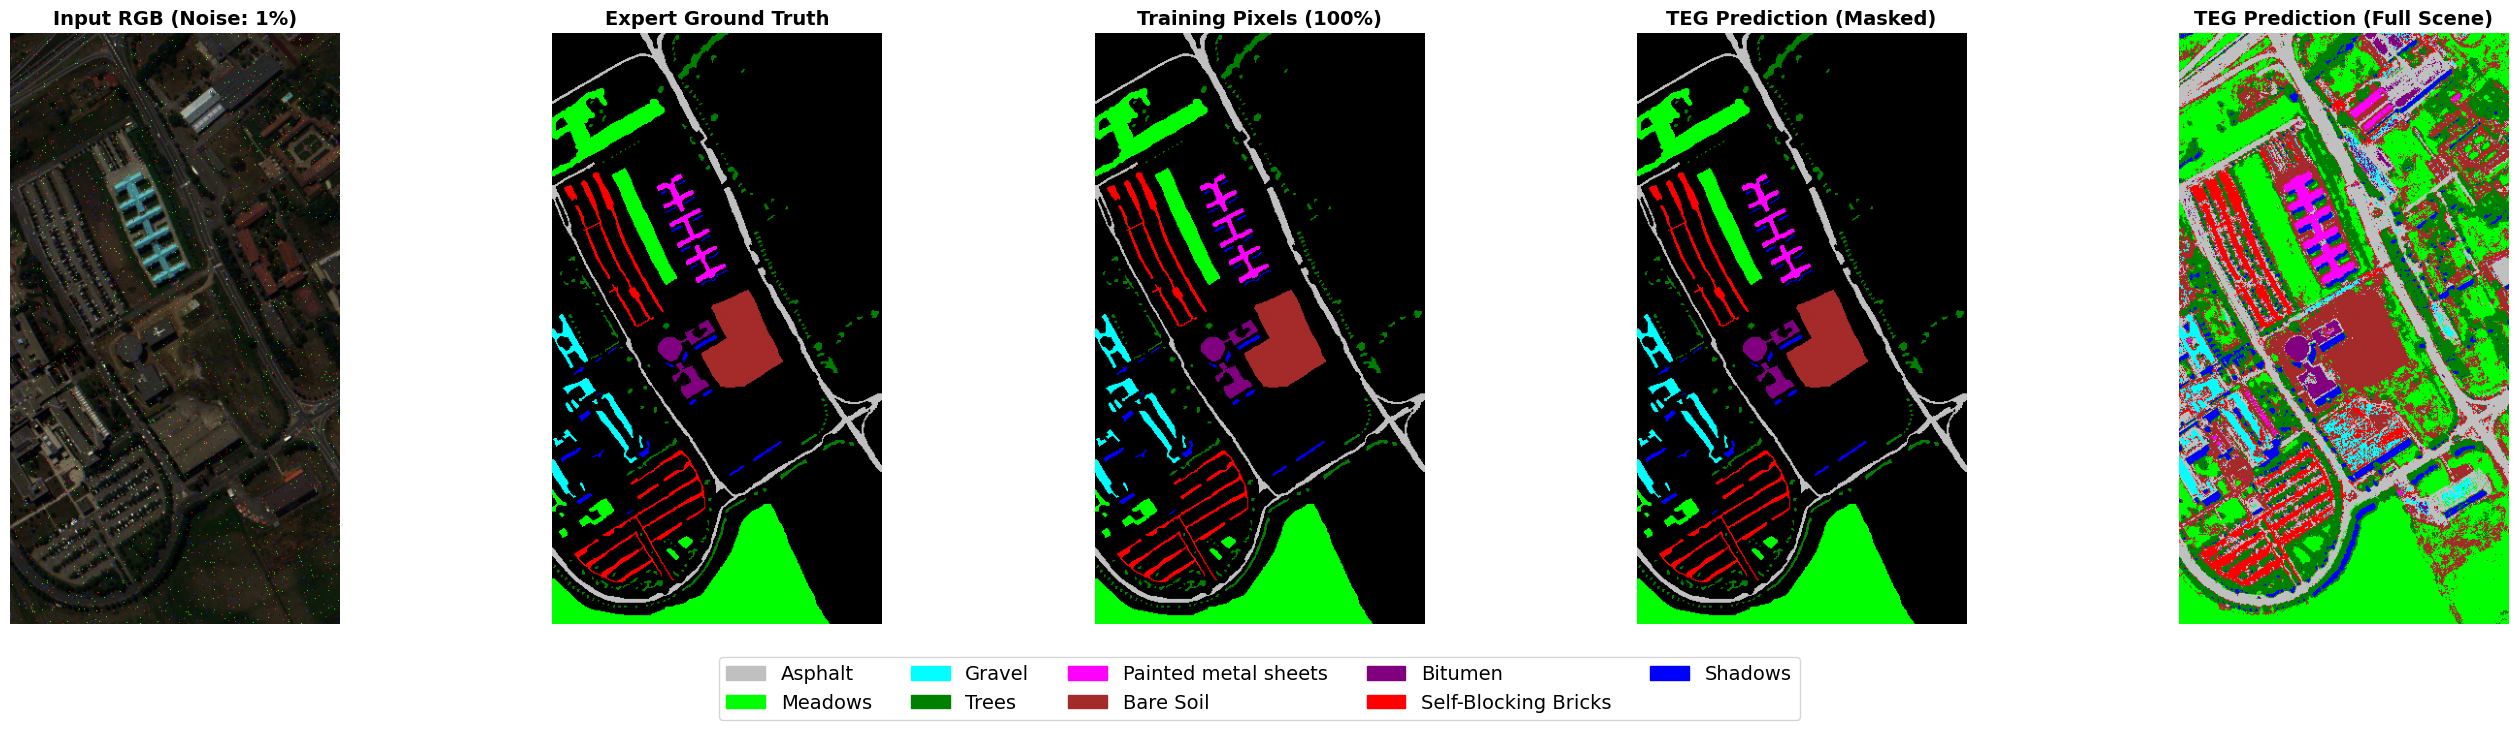

In [76]:
# =============================================================================
# MAIN 5: FULL INFERENCE & CLASSIFICATION MAP (З вибором обсягу тренування)
# =============================================================================
warnings.filterwarnings('ignore')

# 1. Офіційна палітра кольорів Pavia University (10 класів, де 0 - Фон)
pavia_colors = np.array([
    [0, 0, 0],         # 0: Undefined (Black)
    [192, 192, 192],   # 1: Asphalt (Silver/Gray)
    [0, 255, 0],       # 2: Meadows (Light Green)
    [0, 255, 255],     # 3: Gravel (Cyan)
    [0, 128, 0],       # 4: Trees (Dark Green)
    [255, 0, 255],     # 5: Painted metal sheets (Magenta)
    [165, 42, 42],     # 6: Bare Soil (Brown)
    [128, 0, 128],     # 7: Bitumen (Purple)
    [255, 0, 0],       # 8: Self-Blocking Bricks (Red)
    [0, 0, 255]        # 9: Shadows (Blue)
]) / 255.0

pavia_cmap = ListedColormap(pavia_colors)

class_names = ['Undefined', 'Asphalt', 'Meadows', 'Gravel', 'Trees', 
               'Painted metal sheets', 'Bare Soil', 'Bitumen', 
               'Self-Blocking Bricks', 'Shadows']

# 2. Головна функція повного інференсу
def run_full_inference(noise_level, train_fraction):
    print(f"[*] 1. Генерація даних (Рівень шуму: {int(noise_level*100)}%, Тренування: {int(train_fraction*100)}%)...")
    current_cube = data if noise_level == 0 else add_sp_noise_cube(data, noise_ratio=noise_level)
    
    print("[*] 2. Екстракція TEG ознак для ВСІЄЇ сцени (610x340)...")
    rgb = get_rgb_image(current_cube)
    features = [rgb]
    lbp_configs = [(1, 8), (2, 16), (3, 24)]
    
    for ch_idx in range(3):
        ch = rgb[:, :, ch_idx]
        features.append(sobel(ch)[:, :, np.newaxis])
        ch_8bit = (ch * 255).astype(np.uint8)
        features.append(entropy(ch_8bit, disk(3))[:, :, np.newaxis])
        for r, p in lbp_configs:
            lbp_map = local_binary_pattern(ch, p, r, method='uniform')
            features.append((lbp_map / lbp_map.max())[:, :, np.newaxis])
            
    teg_cube = np.concatenate(features, axis=2)
    h, w, b = teg_cube.shape
    
    X_all_raw = teg_cube.reshape(h * w, b)
    
    # Виділяємо індекси та класи валідних пікселів
    valid_indices = np.where(gt != 0)
    y_valid = gt[valid_indices]
    
    # Розподіл на тренування відповідно до train_fraction
    print(f"[*] 3. Формування тренувальної вибірки ({int(train_fraction*100)}% від розмічених даних)...")
    if train_fraction < 1.0:
        train_idx, _ = train_test_split(
            np.arange(len(y_valid)), 
            train_size=train_fraction, 
            stratify=y_valid, 
            random_state=42
        )
    else:
        train_idx = np.arange(len(y_valid))
        
    # Створюємо 2D маску для візуалізації тренувальних пікселів
    train_mask_2d = np.zeros_like(gt, dtype=bool)
    train_mask_2d[valid_indices[0][train_idx], valid_indices[1][train_idx]] = True
    
    # Створюємо кольорову карту тренувальних даних
    gt_train_viz = np.zeros_like(gt)
    gt_train_viz[train_mask_2d] = gt[train_mask_2d]
    
    # Витягуємо ознаки та мітки тільки для тренування
    X_train_raw = X_all_raw[train_mask_2d.flatten()]
    y_train = gt.flatten()[train_mask_2d.flatten()] - 1 
    
    print("[*] 4. Нормалізація та навчання XGBoost...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_all = scaler.transform(X_all_raw) 
    
    clf = xgb.XGBClassifier(
        objective='multi:softmax',
        n_estimators=400,
        max_depth=12,
        eta=0.3,
        use_label_encoder=False,
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    print("[*] 5. Прогнозування класів для всього університету...")
    y_pred_all = clf.predict(X_all) + 1 
    prediction_map = y_pred_all.reshape(h, w)
    
    prediction_masked = np.copy(prediction_map)
    prediction_masked[~ (gt != 0)] = 0
    
    print("[+] Готово! Будуємо карти...")
    
    # 3. Візуалізація (Тепер 5 колонок)
    fig, axes = plt.subplots(1, 5, figsize=(28, 7))
    
    axes[0].imshow(rgb)
    axes[0].set_title(f'Input RGB (Noise: {int(noise_level*100)}%)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[1].set_title('Expert Ground Truth', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # НОВИЙ ГРАФІК: Тренувальна маска
    axes[2].imshow(gt_train_viz, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[2].set_title(f'Training Pixels ({int(train_fraction*100)}%)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(prediction_masked, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[3].set_title('TEG Prediction (Masked)', fontsize=14, fontweight='bold')
    axes[3].axis('off')
    
    axes[4].imshow(prediction_map, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[4].set_title('TEG Prediction (Full Scene)', fontsize=14, fontweight='bold')
    axes[4].axis('off')
    
    patches = [mpatches.Patch(color=pavia_colors[i], label=class_names[i]) for i in range(1, 10)]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=14, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# =============================================================================
# ЗАПУСК ЕКСПЕРИМЕНТУ
# =============================================================================
# Налаштуйте ці два параметри під ваші потреби:
NOISE_LEVEL = 0.01       # Рівень шуму (0.0 для чистого, 0.05 для 5%, 0.10 для 10%)
TRAIN_FRACTION = 1.0    # Обсяг тренувальних даних (наприклад, 0.10 - це 10%)

run_full_inference(noise_level=NOISE_LEVEL, train_fraction=TRAIN_FRACTION)

# 3D-CNN
Source: https://github.com/xiachangxue/DeepHyperX
3D CNN (Spectral–Spatial Classification of Hyperspectral Imagery with 3D Convolutional Neural Network, Li et al., Remote Sensing 2017)

In [16]:
# =============================================================================
# PyTorch 3D-CNN BASELINE (Li et al., 2017)
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time

# Перевірка наявності GPU (CUDA) або використання CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Використовується пристрій для 3D-CNN: {device}")

# -----------------------------------------------------------------------------
# 1. Архітектура Shallow 3D-CNN (Li et al.)
# -----------------------------------------------------------------------------
class Li_3D_CNN(nn.Module):
    def __init__(self, in_channels=1, bands=103, num_classes=9, patch_size=5):
        super(Li_3D_CNN, self).__init__()
        # Вхідний тензор: (Batch_Size, 1, Bands, Patch_H, Patch_W)
        
        # Шар 1: Згортка (Спектрально-просторова)
        # Ядро: 7 по спектру, 3x3 по простору
        self.conv1 = nn.Conv3d(in_channels, 8, kernel_size=(7, 3, 3), stride=1, padding=0)
        self.relu1 = nn.ReLU()
        
        # Шар 2: Згортка (Спектрально-просторова)
        # Ядро: 5 по спектру, 3x3 по простору (зменшує просторовий розмір до 1x1)
        self.conv2 = nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=1, padding=0)
        self.relu2 = nn.ReLU()
        
        # Розрахунок розміру після згорток (для Flatten)
        # При Patch=5, після conv1 (3x3 kernel) -> просторовий розмір 3x3
        # Після conv2 (3x3 kernel) -> просторовий розмір 1x1
        # Спектральний вимір: 103 -> 97 (після 7) -> 93 (після 5)
        flatten_features = 16 * (bands - 6 - 4) * 1 * 1 
        
        self.fc1 = nn.Linear(flatten_features, 256)
        self.dropout = nn.Dropout(p=0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1) # Flatten
        x = self.relu1(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# -----------------------------------------------------------------------------
# 2. Механізм витягування 3D патчів
# -----------------------------------------------------------------------------
def create_3d_patches(cube, gt, patch_size=5):
    """
    Нарізає гіперспектральний куб на 3D патчі (вікна) навколо кожного розміченого пікселя.
    cube: (H, W, Bands)
    gt: (H, W)
    """
    print(f"[*] Формування 3D патчів (розмір вікна: {patch_size}x{patch_size})...")
    h, w, b = cube.shape
    margin = patch_size // 2
    
    # Нормалізація всього куба перед нарізанням (Standard Scaling)
    cube_flat = cube.reshape(-1, b)
    cube_norm = StandardScaler().fit_transform(cube_flat).reshape(h, w, b)
    
    # Додаємо нульовий відступ (Zero Padding), щоб обробити краї зображення
    padded_cube = np.pad(cube_norm, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    
    patches = []
    labels = []
    
    # Знаходимо координати всіх валідних пікселів
    valid_coords = np.argwhere(gt != 0)
    
    for y, x in valid_coords:
        # Витягуємо патч (з урахуванням зсуву через padding)
        patch = padded_cube[y : y + patch_size, x : x + patch_size, :]
        patches.append(patch)
        labels.append(gt[y, x] - 1) # Класи від 0 до 8
        
    patches = np.array(patches)
    labels = np.array(labels)
    
    # Змінюємо розмірність для PyTorch: (Batch, Channels, Depth(Bands), Height, Width)
    # З (N, H, W, B) робимо (N, 1, B, H, W)
    patches = np.transpose(patches, (0, 3, 1, 2))
    patches = np.expand_dims(patches, axis=1)
    
    print(f"[+] Створено {patches.shape[0]} патчів. Формат тензора: {patches.shape}")
    return patches, labels

[*] Використовується пристрій для 3D-CNN: cpu


# Цикл навчання та тестування

In [17]:
# =============================================================================
# ТРЕНУВАННЯ ТА ОЦІНКА 3D-CNN НА ЗАШУМЛЕНИХ ДАНИХ (5% Noise)
# =============================================================================

# 1. Беремо ваш зашумлений куб з Main 1
target_noise_level = 0.05
noisy_cube_3d = noisy_datasets[target_noise_level]

# 2. Формуємо патчі (це потребуватиме трохи оперативної пам'яті)
X_patches, y_labels = create_3d_patches(noisy_cube_3d, gt, patch_size=5)

# 3. Розбиття на Train / Test (візьмемо 10% для тренування, як у ваших експериментах)
train_fraction = 0.10
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_patches, y_labels, train_size=train_fraction, stratify=y_labels, random_state=42
)

print(f"[*] Тренувальна вибірка: {X_train_np.shape[0]} зразків")
print(f"[*] Тестова вибірка:     {X_test_np.shape[0]} зразків")

# 4. Конвертація NumPy масивів у PyTorch Тензори
X_train_t = torch.FloatTensor(X_train_np)
y_train_t = torch.LongTensor(y_train_np)
X_test_t = torch.FloatTensor(X_test_np)
y_test_t = torch.LongTensor(y_test_np)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# 5. Ініціалізація моделі
model = Li_3D_CNN(in_channels=1, bands=103, num_classes=9, patch_size=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Цикл тренування (Training Loop)
epochs = 30
print("\n--- ПОЧАТОК ТРЕНУВАННЯ 3D-CNN ---")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}")

train_time = time.time() - start_time
print(f"[+] Тренування завершено за {train_time:.2f} секунд.")

# 7. Оцінка (Inference / Evaluation)
print("\n--- ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ ---")
model.eval()
all_preds = []
all_targets = []

inf_start = time.time()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

inf_time = time.time() - inf_start

# 8. Розрахунок метрик
f1_3dcnn = f1_score(all_targets, all_preds, average='macro')
acc_3dcnn = accuracy_score(all_targets, all_preds)

print(f"Результати Shallow 3D-CNN (Li et al.) при {int(target_noise_level*100)}% шумі та {int(train_fraction*100)}% тренувальних даних:")
print(f" > Обчислювальний час (Inference): {inf_time:.4f} секунд")
print(f" > Overall Accuracy (OA):          {acc_3dcnn:.4f}")
print(f" > F1-Macro Score:                 {f1_3dcnn:.4f}")

# Для порівняння, ви можете зіставити це з метриками XGBoost з Main 3 (де F1 для TEG при 10% Train був ~0.8002)

[*] Формування 3D патчів (розмір вікна: 5x5)...
[+] Створено 42776 патчів. Формат тензора: (42776, 1, 103, 5, 5)
[*] Тренувальна вибірка: 4277 зразків
[*] Тестова вибірка:     38499 зразків

--- ПОЧАТОК ТРЕНУВАННЯ 3D-CNN ---
Epoch [1/30] - Loss: 0.9230
Epoch [5/30] - Loss: 0.3780
Epoch [10/30] - Loss: 0.1671
Epoch [15/30] - Loss: 0.0628
Epoch [20/30] - Loss: 0.0230
Epoch [25/30] - Loss: 0.0184
Epoch [30/30] - Loss: 0.0164
[+] Тренування завершено за 21.48 секунд.

--- ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ ---
Результати Shallow 3D-CNN (Li et al.) при 5% шумі та 10% тренувальних даних:
 > Обчислювальний час (Inference): 1.9802 секунд
 > Overall Accuracy (OA):          0.8732
 > F1-Macro Score:                 0.8541
